In [1]:
lapply(c('viridis', 'ggthemes', 'skimr'),
       function(pkg_name) { if(! pkg_name %in% installed.packages()) { install.packages(pkg_name)} } )

library(viridis)    # A nice color scheme for plots.
library(ggthemes)   # Common themes to change the look and feel of plots.
library(scales)     # Graphical scales map data to aesthetics in plots.
library(skimr)      # Better summaries of data.
library(lubridate)  # Date library from the tidyverse.
library(tidyverse)  # Data wrangling packages.
library(bigrquery)  # Data extraction from Google BigQuery

## Plot setup.
theme_set(theme_bw(base_size = 14)) # Default theme for plots.

#' Returns a data frame with a y position and a label, for use annotating ggplot boxplots.
#'
#' @param d A data frame.
#' @return A data frame with column y as max and column label as length.
get_boxplot_fun_data <- function(df) {
  return(data.frame(y = max(df), label = stringr::str_c('N = ', length(df))))
}

my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

#install.packages("psych")
library(psych)

#install.packages("lavaan") 
library(lavaan)

#install.packages("semTools")
library(semTools)

R.version

set.seed(123)

[[1]]
NULL

[[2]]
NULL

[[3]]
NULL

Loading required package: viridisLite


Attaching package: ‘scales’


The following object is masked from ‘package:viridis’:

    viridis_pal



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr   1.1.4     ✔ readr   2.1.5
✔ forcats 1.0.0     ✔ stringr 1.5.1
✔ ggplot2 3.5.2     ✔ tibble  3.2.1
✔ purrr   1.0.4     ✔ tidyr   1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ readr::col_factor() masks scales::col_factor()
✖ purrr::discard()    masks scales::discard()
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘psych’


The following objects are masked from ‘package:ggplot2’:

    %+%, alpha


The following objects are masked fro

               _                           
platform       x86_64-pc-linux-gnu         
arch           x86_64                      
os             linux-gnu                   
system         x86_64, linux-gnu           
status                                     
major          4                           
minor          5.0                         
year           2025                        
month          04                          
day            11                          
svn rev        88135                       
language       R                           
version.string R version 4.5.0 (2025-04-11)
nickname       How About a Twenty-Six      

In [2]:
# This snippet assumes that you run setup first

# This code copies a file from your Google Bucket into a dataframe

# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'All_SDoH_data_domain_filtered_60.csv'

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
sdoh_data  <- read_csv(name_of_file_in_bucket)

nrow(sdoh_data)
colnames(sdoh_data)

character(0)

Rows: 54313 Columns: 54
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (6): SexGender, where_born, military, healthcare, disabled, sexual_ori...
dbl  (37): person_id, race_unknown, age_today, LGBTQIA, ehr_length, relative...
lgl   (8): AIAN, Asian, Black, Mid, Multiple, PI, White, His
date  (3): date_of_birth, min_date, max_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] 54313

[1] "person_id"                 "date_of_birth"            
 [3] "AIAN"                      "Asian"                    
 [5] "Black"                     "Mid"                      
 [7] "Multiple"                  "PI"                       
 [9] "White"                     "His"                      
[11] "race_unknown"              "SexGender"                
[13] "age_today"                 "where_born"               
[15] "military"                  "healthcare"               
[17] "disabled"                  "sexual_orientation"       
[19] "LGBTQIA"                   "min_date"                 
[21] "max_date"                  "ehr_length"               
[23] "relative_health"           "record_depth"             
[25] "visit_frequency"           "age"                      
[27] "Education"                 "employment"               
[29] "income"                    "Own Home"                 
[31] "number_living"             "Health Literacy"          
[33] "Housing Quality"           "Housing Instability"      
[35] "Food Insecurity"           "Walkability"              
[37] "Loneliness"                "Crime"                    
[39] "Physical Disorder"         "Social Disorder"          
[41] "Everyday Discrimination"   "Medical Discrimination"   
[43] "Social Cohesion"           "Stress"                   
[45] "Social Support"            "Spiritual Experiences"    
[47] "Health Coverage"           "Healthcare Utilization"   
[49] "Delayed Care"              "Can't afford care"        
[51] "Worried Pay"               "Respect"                  
[53] "Percent Poverty Threshold" "age2"

# Plot distributions

In [3]:
SCC<-c("Social Support", "Loneliness", "Social Cohesion", "Everyday Discrimination", "Stress", "Spiritual Experiences")
NBE<-c("Crime", "Physical Disorder", "Social Disorder", "Walkability")
ES<-c("Own Home","Housing Quality", "Housing Instability", "Food Insecurity", "Percent Poverty Threshold")
HCAU<-c("Health Literacy", "Medical Discrimination", "Health Coverage", "Healthcare Utilization",
        "Delayed Care", "Can't afford care", "Worried Pay", "Respect")
education<-c("Education")

all_vars <- c(SCC, NBE, ES, HCAU, education)


# Convert to long format with domain annotation
sdoh_data_long <- sdoh_data %>%
  pivot_longer(
    cols = all_of(all_vars),
    names_to = "SDoH_variable",
    values_to = "value"
  )

sdoh_data_long <- sdoh_data_long %>%
  mutate(
    Domain = case_when(
      SDoH_variable %in% SCC ~ "SCC",
      SDoH_variable %in% NBE ~ "NBE",
      SDoH_variable %in% ES ~ "ES",
      SDoH_variable %in% HCAU ~ "HCAU",
      SDoH_variable %in% education ~ "Education",
      TRUE ~ "SDOH"  # Fallback for domains not in any list
    )
  )

# Custom colors for Domain
custom_colors <- c(
  "HCAU" = "#ED6B6B",
  "ES" = "#2AC6A0",
  "Education" = "#0D1940",
  "SCC" = "#FAB316",
  "NBE" = "#19B2E3"
)


In [4]:
sdoh_data_long <- sdoh_data_long %>%
  mutate(SDoH_variable = factor(SDoH_variable, levels = all_vars))

# Determine which variables are binary (only 0 and 1)
binary_vars <- c("Own Home", "Housing Quality", "Housing Instability", "Food Insecurity",
                "Health Literacy", "Health Coverage", "Delayed Care", "Can't afford care")

# Add a column to indicate binary status
sdoh_data_long <- sdoh_data_long %>%
  mutate(var_type = ifelse(SDoH_variable %in% binary_vars, "binary", "continuous"))



Warning message:
“Removed 32937 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 13738 rows containing non-finite outside the scale range
(`stat_summary()`).”


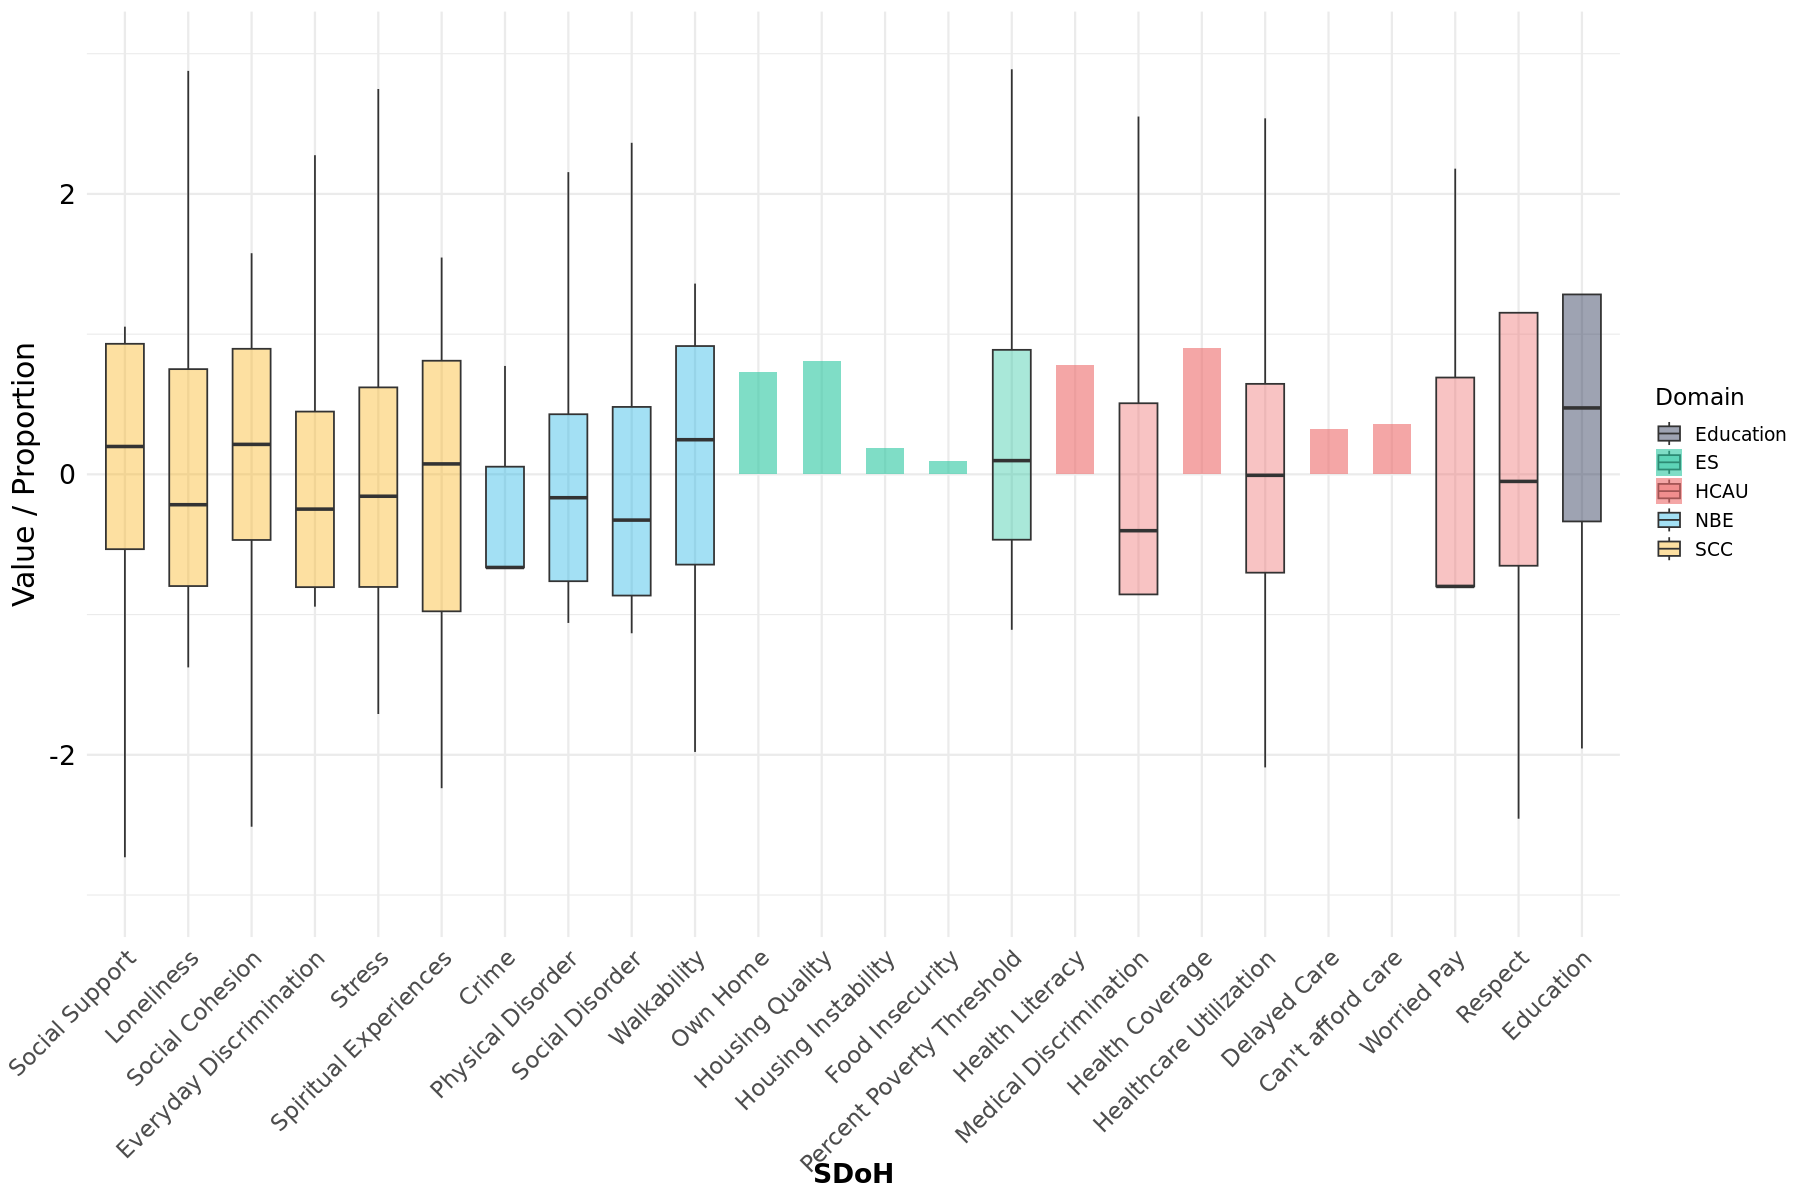

In [5]:
options(repr.plot.width = 15, repr.plot.height = 10)

ggplot(sdoh_data_long, aes(x = SDoH_variable, y = value, fill = Domain)) +
  # Continuous vars: boxplot
  geom_boxplot(data = subset(sdoh_data_long, var_type == "continuous"),
               outlier.shape = NA, alpha = 0.4, width = 0.6) +
  # Binary vars: bar for proportion
  stat_summary(data = subset(sdoh_data_long, var_type == "binary"),
               fun = mean, geom = "bar", width = 0.6, alpha = 0.6) +
  scale_fill_manual(values = custom_colors) +
  scale_x_discrete(limits = all_vars) +  # Enforce order
  scale_y_continuous(limits = c(-3, 3)) +
  labs(
    x = "SDoH",
    y = "Value / Proportion"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 18),
    axis.text.x = element_text(size = 14, angle = 45, hjust = 1),
    axis.text.y = element_text(size = 16, color = "black")
  )


# Prepare data

In [6]:
# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'Case_Control_df.csv'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
Case_Control_df  <- read_csv(name_of_file_in_bucket)

character(0)

Rows: 265954 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (10): person_id, Asthma, Afib, BreastC, CKD, CHD, HyperC, ProstateC, t2d...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [7]:
sdoh_data<-merge(sdoh_data, Case_Control_df, on="person_id", how="left")

In [8]:
colnames(sdoh_data) <- make.names(colnames(sdoh_data))

In [9]:
# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'imputed_individual_level_SDOH.csv'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
imputed_sdoh <- read_csv(name_of_file_in_bucket)

colnames(imputed_sdoh) <- make.names(colnames(imputed_sdoh))


imputed_sdoh <- imputed_sdoh %>%
  mutate(SexGender = as.factor(SexGender)) %>%
  mutate(dummy = 1) %>%
  pivot_wider(
    names_from = SexGender,
    values_from = dummy,
    values_fill = 0,
    names_prefix = ""
  )

cov_cols <- c("record_depth", "visit_frequency", "age", "age2")

# Standardize columns (z-score)
imputed_sdoh[cov_cols] <- lapply(imputed_sdoh[cov_cols], function(x) {
  (x - mean(x, na.rm = TRUE)) / sd(x, na.rm = TRUE)
})
imputed_sdoh<-merge(imputed_sdoh, Case_Control_df, on="person_id", how="left")



character(0)

Rows: 54313 Columns: 37
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): SexGender
dbl (30): person_id, race_unknown, record_depth, visit_frequency, age, Educa...
lgl  (6): Black, Mid, Multiple, White, His, AANHPI

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Set up functions

In [10]:
diseases <- c(
  "Asthma", "Afib", "BreastC", "CKD",
  "CHD", "HyperC", "ProstateC", "t2d", "t1d"
)

build_model <- function(disease, model_A, domain) {

  predictors <- c("age", "age2", "record_depth", "visit_frequency")

  if (disease %in% c("BreastC", "ProstateC")) {
    predictors <- c(predictors, "SGM")
  } else if (disease %in% c("t1d", "CKD")) {
    predictors <- c(predictors, "Cis_male")
  } else {
    predictors <- c(predictors, "Cis_male", "SGM")
  }

  regression_part <- paste(disease, "~", paste(c(predictors, domain), collapse = " + "))

  model <- paste0(model_A, regression_part)

  return(model)
}

In [11]:
fit_sem_extract <- function(disease, data, model_A, domain) {
  
  message("Fitting model for: ", disease)

  # Build model string
  model_string <- build_model(disease, model_A, domain)

  # Subset to non-missing outcome
  data_subset <- dplyr::filter(
    data,
    !is.na(.data[[disease]])
  )
    
  if (disease %in% c("t1d", "CKD")) {
    data_subset <- filter(data_subset, SGM == 0)
  }

  # Fit SEM
  fit <- lavaan::sem(
    model = model_string,
    data  = data_subset,
    estimator = "MLR"
  )

  # Check convergence
  if (!lavaan::lavInspect(fit, "converged")) {
    warning(paste("Model did not converge for", disease))
  }
    

  # ---- Fit indices ----
  fit_indices <- data.frame(
      Disease = as.character(disease),
      cfi     = as.numeric(lavaan::fitMeasures(fit, "cfi")),
      rmsea   = as.numeric(lavaan::fitMeasures(fit, "rmsea")),
      srmr    = as.numeric(lavaan::fitMeasures(fit, "srmr"))
    )

  # ---- Coefficients (structural paths only) ----
  coef_df <- lavaan::parameterEstimates(
    fit,
    standardized = TRUE
  ) %>%
    dplyr::filter(
      op == "~",
      lhs == disease,
      !is.na(se)   # drop fixed / non-estimated paths
    ) %>%
    dplyr::select(
      Disease = lhs,
      term = rhs,
      estimate = est,
      std.error = se,
      z.value = z,
      p.value = pvalue,
      std_estimate = std.all
    )

  return(list(
    coef_df = coef_df,
    fit_indices = fit_indices,
    fit = fit
  ))
}

# Social and Community Context

In [12]:
#Specify the model
model <- '
SCC =~ NA*Social.Support + Loneliness + Social.Cohesion + Everyday.Discrimination + Stress + Spiritual.Experiences
SCC ~~ 1*SCC
Social.Support ~~ Loneliness
Social.Support ~~ Social.Cohesion
'



In [13]:
# Fit the model - can also impute
fit <- lavaan::sem(model, data = sdoh_data, missing = "fiml")


In [14]:
# Summary of the model
summary(fit, fit.measures = TRUE, standardized = TRUE)
#standardizedsolution(fit)
#summary(fit)$pe

,lhs,op,rhs,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,SCC,=~,Social.Support,0,0.423316852,0.004925114,85.9506772,0.000000e+00,0.423316852,0.431445652
2,SCC,=~,Loneliness,0,-0.735220403,0.004424041,-166.1875193,0.000000e+00,-0.735220403,-0.735736403
3,SCC,=~,Social.Cohesion,0,0.453330198,0.004638856,97.7245728,0.000000e+00,0.453330198,0.458086645
4,SCC,=~,Everyday.Discrimination,0,-0.611174289,0.004400156,-138.8983163,0.000000e+00,-0.611174289,-0.623987547
5,SCC,=~,Stress,0,-0.761212086,0.004444029,-171.2887208,0.000000e+00,-0.761212086,-0.761436342
6,SCC,=~,Spiritual.Experiences,0,0.159185589,0.004905553,32.4500808,0.000000e+00,0.159185589,0.158258220
7,SCC,~~,SCC,0,1.000000000,0.000000000,NA,NA,1.000000000,1.000000000
8,Social.Support,~~,Loneliness,0,-0.271073345,0.003837425,-70.6393925,0.000000e+00,-0.271073345,-0.452499462
9,Social.Support,~~,Social.Cohesion,0,0.110131748,0.003255483,33.8296169,0.000000e+00,0.110131748,0.141441234


In [15]:
my_dataframe <- parameterEstimates(fit, standardized = TRUE)

destination_filename <- 'SCC_CFA_statistics.csv'

# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)



character(0)

In [16]:
# Request modification indices
mod_indices <- modindices(fit, sort=TRUE)
mod_indices

,lhs,op,rhs,mi,epc,sepc.lv,sepc.all,sepc.nox
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
27,Loneliness,~~,Everyday.Discrimination,507.863274,-0.087104769,-0.087104769,-0.168152937,-0.168152937
34,Everyday.Discrimination,~~,Spiritual.Experiences,453.652804,0.078487279,0.078487279,0.103249522,0.103249522
31,Social.Cohesion,~~,Stress,384.202956,0.075857078,0.075857078,0.133065297,0.133065297
29,Loneliness,~~,Spiritual.Experiences,363.107579,-0.059887345,-0.059887345,-0.089094231,-0.089094231
25,Social.Support,~~,Spiritual.Experiences,307.491860,-0.059668854,-0.059668854,-0.067874275,-0.067874275
23,Social.Support,~~,Everyday.Discrimination,174.396268,-0.042084621,-0.042084621,-0.062119639,-0.062119639
30,Social.Cohesion,~~,Everyday.Discrimination,157.796203,-0.044243066,-0.044243066,-0.065711289,-0.065711289
33,Everyday.Discrimination,~~,Stress,154.321996,0.063991225,0.063991225,0.129012299,0.129012299
28,Loneliness,~~,Stress,107.958685,0.053432282,0.053432282,0.121826052,0.121826052


In [17]:
SCC_factor_scores <- lavPredict(fit, method = "Bartlett")
SCC_factor_scores_with_id <- data.frame(person_id = sdoh_data$person_id, SCC_factor_scores)

merged<-merge(sdoh_data, SCC_factor_scores_with_id, by="person_id")

In [18]:
names(merged)

[1] "person_id"                 "date_of_birth"            
 [3] "AIAN"                      "Asian"                    
 [5] "Black"                     "Mid"                      
 [7] "Multiple"                  "PI"                       
 [9] "White"                     "His"                      
[11] "race_unknown"              "SexGender"                
[13] "age_today"                 "where_born"               
[15] "military"                  "healthcare"               
[17] "disabled"                  "sexual_orientation"       
[19] "LGBTQIA"                   "min_date"                 
[21] "max_date"                  "ehr_length"               
[23] "relative_health"           "record_depth"             
[25] "visit_frequency"           "age"                      
[27] "Education"                 "employment"               
[29] "income"                    "Own.Home"                 
[31] "number_living"             "Health.Literacy"          
[33] "Housing.Quality"           "Housing.Instability"      
[35] "Food.Insecurity"           "Walkability"              
[37] "Loneliness"                "Crime"                    
[39] "Physical.Disorder"         "Social.Disorder"          
[41] "Everyday.Discrimination"   "Medical.Discrimination"   
[43] "Social.Cohesion"           "Stress"                   
[45] "Social.Support"            "Spiritual.Experiences"    
[47] "Health.Coverage"           "Healthcare.Utilization"   
[49] "Delayed.Care"              "Can.t.afford.care"        
[51] "Worried.Pay"               "Respect"                  
[53] "Percent.Poverty.Threshold" "age2"                     
[55] "Asthma"                    "Afib"                     
[57] "BreastC"                   "CKD"                      
[59] "CHD"                       "HyperC"                   
[61] "ProstateC"                 "t2d"                      
[63] "t1d"                       "SCC"

## Disease prediction

In [19]:
SCC_model <- "
  SCC =~ -1*Social.Support + Loneliness + Social.Cohesion + 
         Everyday.Discrimination + Stress + Spiritual.Experiences

  Social.Support ~~ Loneliness
  Social.Support ~~ Social.Cohesion

  SCC ~ age
  SCC ~ age2
  "


########Save Data############
results <- purrr::map(diseases, ~ fit_sem_extract(.x, imputed_sdoh, SCC_model, "SCC"))

all_coefs <- purrr::map_dfr(results, "coef_df")
all_fits  <- purrr::map_dfr(results, "fit_indices", .id = "Disease")

destination_filename <- 'SCC_disease_statistics.csv'
# store the dataframe in current workspace
write_excel_csv(all_coefs, destination_filename)
# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)


Fitting model for: Asthma

Fitting model for: Afib

Fitting model for: BreastC

Fitting model for: CKD

Fitting model for: CHD

Fitting model for: HyperC

Fitting model for: ProstateC

Fitting model for: t2d

Fitting model for: t1d



character(0)

In [20]:
ES_model <- "
  ES =~ -1*Own.Home + Housing.Quality + Housing.Instability + Food.Insecurity + Percent.Poverty.Threshold
  Own.Home ~~ Housing.Instability
  Own.Home ~~ Percent.Poverty.Threshold
  Food.Insecurity ~~ Percent.Poverty.Threshold

  ES ~ age
  ES ~ age2

  "

disease <- "t2d"
data <- imputed_sdoh
model_A <- ES_model
domain <- "ES"

  
  message("Fitting model for: ", disease)

  # Build model string
  model_string <- build_model(disease, model_A, domain)

  # Subset to non-missing outcome
  data_subset <- dplyr::filter(
    data,
    !is.na(.data[[disease]])
  )
    
  if (disease %in% c("t1d", "CKD")) {
    data_subset <- filter(data_subset, SGM == 0)
  }

  # Fit SEM
  fit <- lavaan::sem(
    model = model_string,
    data  = data_subset,
    estimator = "MLR"
  )

  # Check convergence
  if (!lavaan::lavInspect(fit, "converged")) {
    warning(paste("Model did not converge for", disease))
  }
    

  # ---- Fit indices ----
  fit_indices <- data.frame(
      Disease = as.character(disease),
      cfi     = as.numeric(lavaan::fitMeasures(fit, "cfi")),
      rmsea   = as.numeric(lavaan::fitMeasures(fit, "rmsea")),
      srmr    = as.numeric(lavaan::fitMeasures(fit, "srmr"))
    )

  # ---- Coefficients (structural paths only) ----
  coef_df <- lavaan::parameterEstimates(
    fit,
    standardized = TRUE
  ) %>%
    dplyr::filter(
      op == "~",
      lhs == disease,
      !is.na(se)   # drop fixed / non-estimated paths
    ) %>%
    dplyr::select(
      Disease = lhs,
      term = rhs,
      estimate = est,
      std.error = se,
      z.value = z,
      p.value = pvalue,
      std_estimate = std.all
    )



Fitting model for: t2d



In [21]:
fit_indices

Disease,cfi,rmsea,srmr
<chr>,<dbl>,<dbl>,<dbl>
t2d,0.8825672,0.05585209,0.04103527


In [22]:
coef_df

Disease,term,estimate,std.error,z.value,p.value,std_estimate
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
t2d,age,0.52433658,0.017853082,29.369527,0.00000000,1.12405090
t2d,age2,-0.36645516,0.017852903,-20.526363,0.00000000,-0.78749858
t2d,record_depth,0.04727462,0.004430903,10.669298,0.00000000,0.10746811
t2d,visit_frequency,0.03764523,0.004519330,8.329826,0.00000000,0.08343289
t2d,Cis_male,0.08405035,0.005454025,15.410702,0.00000000,0.08881010
t2d,SGM,0.04424335,0.017378049,2.545933,0.01089861,0.01407399
t2d,ES,0.55884719,0.020986272,26.629179,0.00000000,0.33147186


In [23]:
modindices(fit, sort=TRUE)

,lhs,op,rhs,mi,epc,sepc.lv,sepc.all,sepc.nox
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
85,visit_frequency,~,t2d,8.155766e+02,1.974597e+00,1.9745967179,0.8909453931,0.8909453931
57,Percent.Poverty.Threshold,~~,t2d,6.726956e+02,-6.406897e-02,-0.0640689689,-0.1742443347,-0.1742443347
60,ES,~,visit_frequency,6.584054e+02,5.094102e-02,0.1876852587,0.1903449691,0.1876852587
59,ES,~,record_depth,4.074372e+02,3.969800e-02,0.1462618567,0.1521481067,0.1462618567
58,ES,~,t2d,3.666297e+02,4.231303e-01,1.5589660954,0.7133794346,0.7133794346
99,SGM,~,t2d,3.010129e+02,2.712732e-01,0.2712731638,0.8527808615,0.8527808615
50,Housing.Quality,~~,Food.Insecurity,2.448035e+02,-1.038420e-02,-0.0103841989,-0.1090756775,-0.1090756775
84,visit_frequency,~,ES,1.640392e+02,2.219497e-01,0.0602409933,0.0593992396,0.0593992396
54,Housing.Instability,~~,Percent.Poverty.Threshold,1.439155e+02,3.106872e-02,0.0310687160,0.0983368530,0.0983368530


# Neighborhood and Built Environment

In [24]:
 # Calculate Cronbach's alpha
columns<-c('Walkability', 'Crime', 'Physical.Disorder', 'Social.Disorder') #, 'housing_type')
df_subset<-sdoh_data[,columns]
alpha(df_subset, check.keys=TRUE)

Warning message in response.frequencies(x, max = max):
“response.frequency has been deprecated and replaced with responseFrequecy.  Please fix your call”
Number of categories should be increased  in order to count frequencies. 




Reliability analysis   
Call: alpha(x = df_subset, check.keys = TRUE)

  raw_alpha std.alpha G6(smc) average_r S/N   ase   mean   sd median_r
      0.72      0.72    0.72      0.39 2.6 0.002 -0.026 0.73     0.35

    95% confidence boundaries 
         lower alpha upper
Feldt     0.71  0.72  0.72
Duhachek  0.71  0.72  0.72

 Reliability if an item is dropped:
                  raw_alpha std.alpha G6(smc) average_r S/N alpha se  var.r
Walkability            0.84      0.84    0.78      0.63 5.1   0.0012 0.0074
Crime                  0.60      0.61    0.61      0.34 1.5   0.0031 0.1059
Physical.Disorder      0.57      0.58    0.56      0.31 1.4   0.0033 0.0765
Social.Disorder        0.54      0.55    0.50      0.29 1.2   0.0034 0.0493
                  med.r
Walkability        0.63
Crime              0.16
Physical.Disorder  0.16
Social.Disorder    0.16

 Item statistics 
                      n raw.r std.r r.cor r.drop    mean   sd
Walkability       52924  0.52  0.50  0.20   0.18  0.0038

In [25]:
#Specify the model
model <- '
NBE =~ NA*Walkability + Crime + Physical.Disorder + Social.Disorder #+ Walkability#+ housing_type
NBE ~~ 1*NBE #fix the variance of the factor to one
#Walkability ~~ nsd_scale
#npd_scale ~~ nsd_scale
#crime_saftey ~~ npd_scale
'   

In [26]:
# Fit the model - can also impute
fit <- lavaan::sem(model, data = sdoh_data, missing = "fiml")

In [27]:
reliability(fit)

Warning message in reliability(fit):
“
The reliability() function was deprecated in 2022 and will cease to be included in future versions of semTools. See help('semTools-deprecated) for details.

It is replaced by the compRelSEM() function, which can estimate alpha and model-based reliability in an even wider variety of models and data types, with greater control in specifying the desired type of reliability coefficient (i.e., more explicitly choosing assumptions). 

The average variance extracted should never have been included because it is not a reliability coefficient. It is now available from the AVE() function.”


,NBE
alpha,0.7179802
omega,0.7605860
omega2,0.7605860
omega3,0.7549935
avevar,0.4850637


In [28]:
# Summary of the model
summary(fit, fit.measures = TRUE, standardized = TRUE)
#standardizedsolution(fit)
#summary(fit)$pe

,lhs,op,rhs,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,NBE,=~,Walkability,0,0.178990041,0.004652944,38.4681292,0.000000e+00,0.178990041,0.178290821
2,NBE,=~,Crime,0,0.670366019,0.004044160,165.7615183,0.000000e+00,0.670366019,0.694645664
3,NBE,=~,Physical.Disorder,0,0.777742128,0.003948305,196.9812851,0.000000e+00,0.777742128,0.787401046
4,NBE,=~,Social.Disorder,0,0.890842579,0.003833612,232.3768335,0.000000e+00,0.890842579,0.908831618
5,NBE,~~,NBE,0,1.000000000,0.000000000,NA,NA,1.000000000,1.000000000
6,Walkability,~~,Walkability,0,0.975821535,0.006029618,161.8380322,0.000000e+00,0.975821535,0.968212383
7,Crime,~~,Crime,0,0.481925961,0.003692913,130.5002376,0.000000e+00,0.481925961,0.517467402
8,Physical.Disorder,~~,Physical.Disorder,0,0.370733990,0.003548134,104.4870233,0.000000e+00,0.370733990,0.379999593
9,Social.Disorder,~~,Social.Disorder,0,0.167204108,0.003726599,44.8677534,0.000000e+00,0.167204108,0.174025090


In [29]:
my_dataframe <- parameterEstimates(fit, standardized = TRUE)

# Replace 'test.csv' with THE NAME of the file you're going to store in the bucket (don't delete the quotation marks)
destination_filename <- 'NBE_CFA_statistics.csv'

# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)


character(0)

In [30]:
# Request modification indices
mod_indices <- modindices(fit, sort=TRUE)
mod_indices

,lhs,op,rhs,mi,epc,sepc.lv,sepc.all,sepc.nox
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
17,Walkability,~~,Social.Disorder,205.83543,-0.04468546,-0.04468546,-0.11062609,-0.11062609
18,Crime,~~,Physical.Disorder,205.83520,-0.14611129,-0.14611129,-0.34567057,-0.34567057
15,Walkability,~~,Crime,125.89350,0.03806506,0.03806506,0.05550743,0.05550743
20,Physical.Disorder,~~,Social.Disorder,125.89292,0.21979672,0.21979672,0.88280857,0.88280857
16,Walkability,~~,Physical.Disorder,54.82178,0.02260260,0.02260260,0.03757871,0.03757871
19,Crime,~~,Social.Disorder,54.82165,0.09696305,0.09696305,0.34158017,0.34158017


In [31]:
NBE_factor_scores <- lavPredict(fit, method = "Bartlett")
NBE_factor_scores_with_id <- data.frame(person_id = sdoh_data$person_id, NBE_factor_scores)

merged<-merge(sdoh_data, NBE_factor_scores_with_id, by="person_id")

## Disease prediction

In [32]:
NBE_model <- "
  NBE =~ NA*Walkability + Crime + Physical.Disorder + Social.Disorder #+ Walkability#+ housing_type
  NBE ~~ 1*NBE #fix the variance of the factor to one

  NBE ~ age
  NBE ~ age2

  "

results <- purrr::map(diseases, ~ fit_sem_extract(.x, imputed_sdoh, NBE_model, "NBE"))

all_coefs <- purrr::map_dfr(results, "coef_df")
all_fits  <- purrr::map_dfr(results, "fit_indices", .id = "Disease")


########Save Data############
my_dataframe <- all_coefs
destination_filename <- 'NBE_disease_statistics.csv'
# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)
# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)


Fitting model for: Asthma

Fitting model for: Afib

Fitting model for: BreastC

Fitting model for: CKD

Fitting model for: CHD

Fitting model for: HyperC

Fitting model for: ProstateC

Fitting model for: t2d

Fitting model for: t1d



character(0)

In [33]:
all_fits

Disease,cfi,rmsea,srmr
<chr>,<dbl>,<dbl>,<dbl>
1,0.9718501,0.03994198,0.02853993
2,0.9697756,0.04026233,0.02770793
3,0.9796784,0.03696919,0.02728661
4,0.9723810,0.04698813,0.03044033
5,0.9720397,0.04015660,0.02654450
6,0.9705020,0.04331868,0.02969936
7,0.9812741,0.03116118,0.03385078
8,0.9665807,0.04378681,0.02943492
9,0.9733601,0.04078207,0.02496568


# Economic Stability

In [34]:
colnames(sdoh_data)

[1] "person_id"                 "date_of_birth"            
 [3] "AIAN"                      "Asian"                    
 [5] "Black"                     "Mid"                      
 [7] "Multiple"                  "PI"                       
 [9] "White"                     "His"                      
[11] "race_unknown"              "SexGender"                
[13] "age_today"                 "where_born"               
[15] "military"                  "healthcare"               
[17] "disabled"                  "sexual_orientation"       
[19] "LGBTQIA"                   "min_date"                 
[21] "max_date"                  "ehr_length"               
[23] "relative_health"           "record_depth"             
[25] "visit_frequency"           "age"                      
[27] "Education"                 "employment"               
[29] "income"                    "Own.Home"                 
[31] "number_living"             "Health.Literacy"          
[33] "Housing.Quality"           "Housing.Instability"      
[35] "Food.Insecurity"           "Walkability"              
[37] "Loneliness"                "Crime"                    
[39] "Physical.Disorder"         "Social.Disorder"          
[41] "Everyday.Discrimination"   "Medical.Discrimination"   
[43] "Social.Cohesion"           "Stress"                   
[45] "Social.Support"            "Spiritual.Experiences"    
[47] "Health.Coverage"           "Healthcare.Utilization"   
[49] "Delayed.Care"              "Can.t.afford.care"        
[51] "Worried.Pay"               "Respect"                  
[53] "Percent.Poverty.Threshold" "age2"                     
[55] "Asthma"                    "Afib"                     
[57] "BreastC"                   "CKD"                      
[59] "CHD"                       "HyperC"                   
[61] "ProstateC"                 "t2d"                      
[63] "t1d"

In [35]:
#Specify the model
model <- '
ES =~ NA*Own.Home + Housing.Quality + Housing.Instability + Food.Insecurity + Percent.Poverty.Threshold
ES ~~ 1*ES #fix the variance of the factor to one
Own.Home ~~ Housing.Instability
Own.Home ~~ Percent.Poverty.Threshold
Food.Insecurity ~~ Percent.Poverty.Threshold
'  

In [36]:
# Fit the model - can also impute
fit <- lavaan::sem(model, data = sdoh_data, missing = "fiml")

In [37]:
# Summary of the model
summary(fit, fit.measures = TRUE, standardized = TRUE)
#standardizedsolution(fit)
#summary(fit)$pe

,lhs,op,rhs,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ES,=~,Own.Home,0,0.202171126,0.0031442218,64.299257,0.000000000,0.202171126,0.45609212
2,ES,=~,Housing.Quality,0,0.146337316,0.0023826971,61.416669,0.000000000,0.146337316,0.37228628
3,ES,=~,Housing.Instability,0,-0.151480387,0.0025607447,-59.154819,0.000000000,-0.151480387,-0.38570642
4,ES,=~,Food.Insecurity,0,-0.185432197,0.0024645050,-75.241154,0.000000000,-0.185432197,-0.63503826
5,ES,=~,Percent.Poverty.Threshold,0,0.453908760,0.0088026776,51.564851,0.000000000,0.453908760,0.45162895
6,ES,~~,ES,0,1.000000000,0.0000000000,NA,NA,1.000000000,1.00000000
7,Own.Home,~~,Housing.Instability,0,-0.031166144,0.0009073288,-34.349340,0.000000000,-0.031166144,-0.21804004
8,Own.Home,~~,Percent.Poverty.Threshold,0,0.069555646,0.0021646224,32.132923,0.000000000,0.069555646,0.19663321
9,Food.Insecurity,~~,Percent.Poverty.Threshold,0,-0.006863399,0.0021540731,-3.186242,0.001441338,-0.006863399,-0.03393239


In [38]:
my_dataframe <- parameterEstimates(fit, standardized = TRUE)

# Replace 'test.csv' with THE NAME of the file you're going to store in the bucket (don't delete the quotation marks)
destination_filename <- 'ES_CFA_statistics.csv'

# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)


character(0)

In [39]:
# Request modification indices
mod_indices <- modindices(fit, sort=TRUE)
mod_indices

,lhs,op,rhs,mi,epc,sepc.lv,sepc.all,sepc.nox
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
26,Housing.Instability,~~,Food.Insecurity,49.43290,0.005136997,0.005136997,0.06285116,0.06285116
25,Housing.Quality,~~,Percent.Poverty.Threshold,27.52688,0.011746628,0.011746628,0.03590708,0.03590708
24,Housing.Quality,~~,Food.Insecurity,27.52687,0.004798767,0.004798767,0.05831437,0.05831437
27,Housing.Instability,~~,Percent.Poverty.Threshold,27.52683,0.012159455,0.012159455,0.03742304,0.03742304
23,Housing.Quality,~~,Housing.Instability,14.04187,0.002715074,0.002715074,0.02053890,0.02053890
21,Own.Home,~~,Housing.Quality,14.04172,0.003623615,0.003623615,0.02517892,0.02517892
22,Own.Home,~~,Food.Insecurity,14.04167,0.004591676,0.004591676,0.05160297,0.05160297


In [40]:
## Disease Prediction
ES_model <- "
  ES =~ -1*Own.Home + Housing.Quality + Housing.Instability + Food.Insecurity + Percent.Poverty.Threshold
  Own.Home ~~ Housing.Instability
  Own.Home ~~ Percent.Poverty.Threshold
  Food.Insecurity ~~ Percent.Poverty.Threshold

  ES ~ age
  ES ~ age2

  "

results <- purrr::map(diseases, ~ fit_sem_extract(.x, imputed_sdoh, ES_model, "ES"))

all_coefs <- purrr::map_dfr(results, "coef_df")
all_fits  <- purrr::map_dfr(results, "fit_indices", .id = "Disease")


########Save Data############
my_dataframe <- all_coefs
destination_filename <- 'ES_disease_statistics.csv'
# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)
# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)


Fitting model for: Asthma

Fitting model for: Afib

Fitting model for: BreastC

Fitting model for: CKD

Fitting model for: CHD

Fitting model for: HyperC

Fitting model for: ProstateC

Fitting model for: t2d

Fitting model for: t1d



character(0)

In [41]:
all_fits

Disease,cfi,rmsea,srmr
<chr>,<dbl>,<dbl>,<dbl>
1,0.8965899,0.05222170,0.03885741
2,0.9108661,0.04703948,0.03628581
3,0.8972201,0.05362232,0.03605952
4,0.9261468,0.05337704,0.03658984
5,0.9069964,0.04913274,0.03508492
6,0.9084870,0.05281155,0.04169483
7,0.8016044,0.06268918,0.05634724
8,0.8825672,0.05585209,0.04103527
9,0.9016838,0.05009237,0.03215091


# Health Care Access and Utilization

In [42]:
colnames(sdoh_data)

[1] "person_id"                 "date_of_birth"            
 [3] "AIAN"                      "Asian"                    
 [5] "Black"                     "Mid"                      
 [7] "Multiple"                  "PI"                       
 [9] "White"                     "His"                      
[11] "race_unknown"              "SexGender"                
[13] "age_today"                 "where_born"               
[15] "military"                  "healthcare"               
[17] "disabled"                  "sexual_orientation"       
[19] "LGBTQIA"                   "min_date"                 
[21] "max_date"                  "ehr_length"               
[23] "relative_health"           "record_depth"             
[25] "visit_frequency"           "age"                      
[27] "Education"                 "employment"               
[29] "income"                    "Own.Home"                 
[31] "number_living"             "Health.Literacy"          
[33] "Housing.Quality"           "Housing.Instability"      
[35] "Food.Insecurity"           "Walkability"              
[37] "Loneliness"                "Crime"                    
[39] "Physical.Disorder"         "Social.Disorder"          
[41] "Everyday.Discrimination"   "Medical.Discrimination"   
[43] "Social.Cohesion"           "Stress"                   
[45] "Social.Support"            "Spiritual.Experiences"    
[47] "Health.Coverage"           "Healthcare.Utilization"   
[49] "Delayed.Care"              "Can.t.afford.care"        
[51] "Worried.Pay"               "Respect"                  
[53] "Percent.Poverty.Threshold" "age2"                     
[55] "Asthma"                    "Afib"                     
[57] "BreastC"                   "CKD"                      
[59] "CHD"                       "HyperC"                   
[61] "ProstateC"                 "t2d"                      
[63] "t1d"

In [43]:
#Specify the model
model <- '
HCAU =~ NA*Health.Literacy + Medical.Discrimination + Health.Coverage + 
 Healthcare.Utilization + Delayed.Care + Can.t.afford.care + Worried.Pay + Respect
HCAU ~~ 1*HCAU #fix the variance of the factor to one
Medical.Discrimination ~~ Respect
Healthcare.Utilization ~~ Worried.Pay
Can.t.afford.care ~~ Worried.Pay
'  

In [44]:
# Fit the model - can also impute
fit <- lavaan::sem(model, data = sdoh_data, missing = "fiml")

In [45]:
# Summary of the model
summary(fit, fit.measures = TRUE, standardized = TRUE)
#standardizedsolution(fit)
#summary(fit)$pe

,lhs,op,rhs,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,HCAU,=~,Health.Literacy,0,0.0783834810,0.0022107308,35.4559138,0.00000000,0.0783834810,0.1889975221
2,HCAU,=~,Medical.Discrimination,0,-0.4082151211,0.0052716260,-77.4362833,0.00000000,-0.4082151211,-0.4150534879
3,HCAU,=~,Health.Coverage,0,0.0950465953,0.0015937395,59.6374716,0.00000000,0.0950465953,0.3136792643
4,HCAU,=~,Healthcare.Utilization,0,-0.1663222507,0.0060387824,-27.5423485,0.00000000,-0.1663222507,-0.1693242985
5,HCAU,=~,Delayed.Care,0,-0.2858519529,0.0026057676,-109.6997120,0.00000000,-0.2858519529,-0.6113393474
6,HCAU,=~,Can.t.afford.care,0,-0.2723161462,0.0028476814,-95.6273236,0.00000000,-0.2723161462,-0.5676008221
7,HCAU,=~,Worried.Pay,0,-0.5614475918,0.0056231236,-99.8462119,0.00000000,-0.5614475918,-0.5871532592
8,HCAU,=~,Respect,0,0.3442374451,0.0053763992,64.0275083,0.00000000,0.3442374451,0.3510314763
9,HCAU,~~,HCAU,0,1.0000000000,0.0000000000,NA,NA,1.0000000000,1.0000000000


In [46]:
my_dataframe <- parameterEstimates(fit, standardized = TRUE)

# Replace 'test.csv' with THE NAME of the file you're going to store in the bucket (don't delete the quotation marks)
destination_filename <- 'HCAU_CFA_statistics.csv'

# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)

character(0)

In [47]:
# Request modification indices
mod_indices <- modindices(fit, sort=TRUE)
mod_indices

,lhs,op,rhs,mi,epc,sepc.lv,sepc.all,sepc.nox
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
47,Healthcare.Utilization,~~,Delayed.Care,3.668390e+02,-4.392986e-02,-4.392986e-02,-0.1226331499,-0.1226331499
38,Medical.Discrimination,~~,Healthcare.Utilization,1.453240e+02,5.154559e-02,5.154559e-02,0.0595042071,0.0595042071
50,Delayed.Care,~~,Can.t.afford.care,1.194205e+02,1.367808e-02,1.367808e-02,0.0935830176,0.0935830176
42,Health.Coverage,~~,Healthcare.Utilization,1.033944e+02,-1.411091e-02,-1.411091e-02,-0.0506619164,-0.0506619164
30,Health.Literacy,~~,Medical.Discrimination,9.931617e+01,-1.612365e-02,-1.612365e-02,-0.0442449554,-0.0442449554
34,Health.Literacy,~~,Can.t.afford.care,7.786644e+01,7.265226e-03,7.265226e-03,0.0451636051,0.0451636051
33,Health.Literacy,~~,Delayed.Care,7.446223e+01,7.326999e-03,7.326999e-03,0.0486204021,0.0486204021
36,Health.Literacy,~~,Respect,4.670055e+01,1.120759e-02,1.120759e-02,0.0299699173,0.0299699173
35,Health.Literacy,~~,Worried.Pay,2.663929e+01,-8.363782e-03,-8.363782e-03,-0.0265320689,-0.0265320689


## Disease Prediction

In [48]:
## Disease Prediction
HCAU_model <- '
HCAU =~ -1*Health.Literacy + Medical.Discrimination + Health.Coverage + 
 Healthcare.Utilization + Delayed.Care + Can.t.afford.care + Worried.Pay + Respect

Medical.Discrimination ~~ Respect
Healthcare.Utilization ~~ Worried.Pay
Can.t.afford.care ~~ Worried.Pay

  HCAU ~ age
  HCAU ~ age2

  

'  

results <- purrr::map(diseases, ~ fit_sem_extract(.x, imputed_sdoh, HCAU_model, "HCAU"))

all_coefs <- purrr::map_dfr(results, "coef_df")
all_fits  <- purrr::map_dfr(results, "fit_indices", .id = "Disease")

########Save Data############
my_dataframe <- all_coefs
destination_filename <- 'HCAU_disease_statistics.csv'
# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)
# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)


Fitting model for: Asthma

Fitting model for: Afib

Fitting model for: BreastC

Fitting model for: CKD

Fitting model for: CHD

Fitting model for: HyperC

Fitting model for: ProstateC

Fitting model for: t2d

Fitting model for: t1d



character(0)

In [49]:
all_fits

Disease,cfi,rmsea,srmr
<chr>,<dbl>,<dbl>,<dbl>
1,0.8227455,0.05737398,0.05678474
2,0.8197282,0.05776302,0.05551570
3,0.8532518,0.05306230,0.05048606
4,0.8546586,0.05941175,0.05970773
5,0.8295533,0.05597452,0.05519818
6,0.8173434,0.06254468,0.06377999
7,0.7172153,0.06387374,0.06402358
8,0.8152492,0.05802814,0.05784094
9,0.8182496,0.05773777,0.05537880


# Education disease prediction

In [50]:
## Disease Prediction
Education_model <- '
Edu=~ -1*Education

  Edu ~ age
  Edu ~ age2
  

'  

results <- purrr::map(diseases, ~ fit_sem_extract(.x, imputed_sdoh, Education_model, "Edu"))

all_coefs <- purrr::map_dfr(results, "coef_df")
all_fits  <- purrr::map_dfr(results, "fit_indices", .id = "Disease")


########Save Data############
my_dataframe <- all_coefs
destination_filename <- 'Education_disease_statistics.csv'
# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)
# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)


Fitting model for: Asthma

Fitting model for: Afib

Fitting model for: BreastC

Fitting model for: CKD

Fitting model for: CHD

Fitting model for: HyperC

Fitting model for: ProstateC

Fitting model for: t2d

Fitting model for: t1d



character(0)

In [51]:
all_fits

Disease,cfi,rmsea,srmr
<chr>,<dbl>,<dbl>,<dbl>
1,0.9352848,0.03901905,0.01682827
2,0.9373624,0.04816601,0.01877277
3,0.9498396,0.02832638,0.01084331
4,0.9889556,0.03869569,0.01534916
5,0.9575418,0.04007470,0.01628002
6,0.9725794,0.05300256,0.02169046
7,0.8502261,0.07507354,0.03184869
8,0.9619898,0.04100059,0.01643802
9,0.8955023,0.03262892,0.01199113


# SDoH

In [52]:
model <- '
SDOH =~NA*Education + SCC + NBE + ES + HCAU
SDOH ~~ 1*SDOH #fix the variance of the factor to one

SCC =~ NA*Social.Support + Loneliness + Social.Cohesion + Everyday.Discrimination + Stress + Spiritual.Experiences
SCC ~~ 1*SCC
Social.Support ~~ Loneliness
Social.Support ~~ Social.Cohesion

NBE =~ NA*Walkability + Crime + Physical.Disorder + Social.Disorder #+ Walkability#+ housing_type
NBE ~~ 1*NBE #fix the variance of the factor to one

ES =~ NA*Own.Home + Housing.Quality + Housing.Instability + Food.Insecurity + Percent.Poverty.Threshold
ES ~~ 1*ES #fix the variance of the factor to one
Own.Home ~~ Housing.Instability
Own.Home ~~ Percent.Poverty.Threshold

HCAU =~ NA*Health.Literacy + Medical.Discrimination + Health.Coverage + 
 Healthcare.Utilization + Delayed.Care + Can.t.afford.care + Worried.Pay + Respect
HCAU ~~ 1*HCAU #fix the variance of the factor to one
Medical.Discrimination ~~ Respect
Healthcare.Utilization ~~ Worried.Pay
Can.t.afford.care ~~ Worried.Pay

Everyday.Discrimination ~~ Medical.Discrimination 
Education ~~ Percent.Poverty.Threshold
Social.Cohesion ~~ Social.Disorder
Education ~~ Health.Literacy
Walkability ~~ Own.Home

NBE =~ Social.Cohesion

' 

In [53]:
# Fit the model - can also impute
fit <- lavaan::sem(model, data = sdoh_data, missing = "fiml")

In [54]:
# Summary of the model
options(max.print = 10000)
print(summary(fit, fit.measures = TRUE, standardized = TRUE))
#standardizedsolution(fit)
#summary(fit)$pe

lavaan 0.6-21 ended normally after 103 iterations

  Estimator                                         ML
  Optimization method                           NLMINB
  Number of model parameters                        89

  Number of observations                         54286
  Number of missing patterns                      1114

Model Test User Model:
                                                       
  Test statistic                              26814.471
  Degrees of freedom                                235
  P-value (Chi-square)                            0.000

Model Test Baseline Model:

  Test statistic                            312136.210
  Degrees of freedom                               276
  P-value                                        0.000

User Model versus Baseline Model:

  Comparative Fit Index (CFI)                    0.915
  Tucker-Lewis Index (TLI)                       0.900
                                                      
  Robust Comparative Fit Index

In [55]:
# Replace df with THE NAME OF YOUR DATAFRAME
my_dataframe <- parameterEstimates(fit, standardized = TRUE)

# Replace 'test.csv' with THE NAME of the file you're going to store in the bucket (don't delete the quotation marks)
destination_filename <- 'SDOH_CFA_statistics.csv'

# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)


character(0)

In [56]:
parameterEstimates(fit, standardized = TRUE)

lhs,op,rhs,est,se,z,pvalue,ci.lower,ci.upper,std.lv,std.all
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SDOH,=~,Education,0.23550515,0.0040492170,58.16067,0,0.22756883,0.24344147,0.23550515,0.28363123
SDOH,=~,SCC,1.69646593,0.0257355517,65.91916,0,1.64602518,1.74690669,0.86147252,0.86147252
SDOH,=~,NBE,-0.62788999,0.0068669568,-91.43643,0,-0.64134898,-0.61443100,-0.53175781,-0.53175781
SDOH,=~,ES,2.60709695,0.0926907406,28.12683,0,2.42542644,2.78876747,0.93367275,0.93367275
SDOH,=~,HCAU,1.94748625,0.0396226490,49.15083,0,1.86982728,2.02514521,0.88957825,0.88957825
SDOH,~~,SDOH,1.00000000,0.0000000000,NA,NA,1.00000000,1.00000000,1.00000000,1.00000000
SCC,=~,Social.Support,0.22636567,0.0033238903,68.10263,0,0.21985097,0.23288038,0.44577354,0.45444655
SCC,=~,Loneliness,-0.34863653,0.0045237000,-77.06889,0,-0.35750282,-0.33977024,-0.68655700,-0.68698421
SCC,=~,Social.Cohesion,0.15137021,0.0028512033,53.08994,0,0.14578195,0.15695846,0.29808775,0.30229718


In [57]:
sdoh_data$SDOH <- lavPredict(fit, method = "Bartlett")[,1]
sdoh_data$SCC <- lavPredict(fit, method = "Bartlett")[,2]
sdoh_data$NBE <- lavPredict(fit, method = "Bartlett")[,3]
sdoh_data$ES<- lavPredict(fit, method = "Bartlett")[,4]
sdoh_data$HCAU<- lavPredict(fit, method = "Bartlett")[,5]
sdoh_data$Education <- sdoh_data$Education

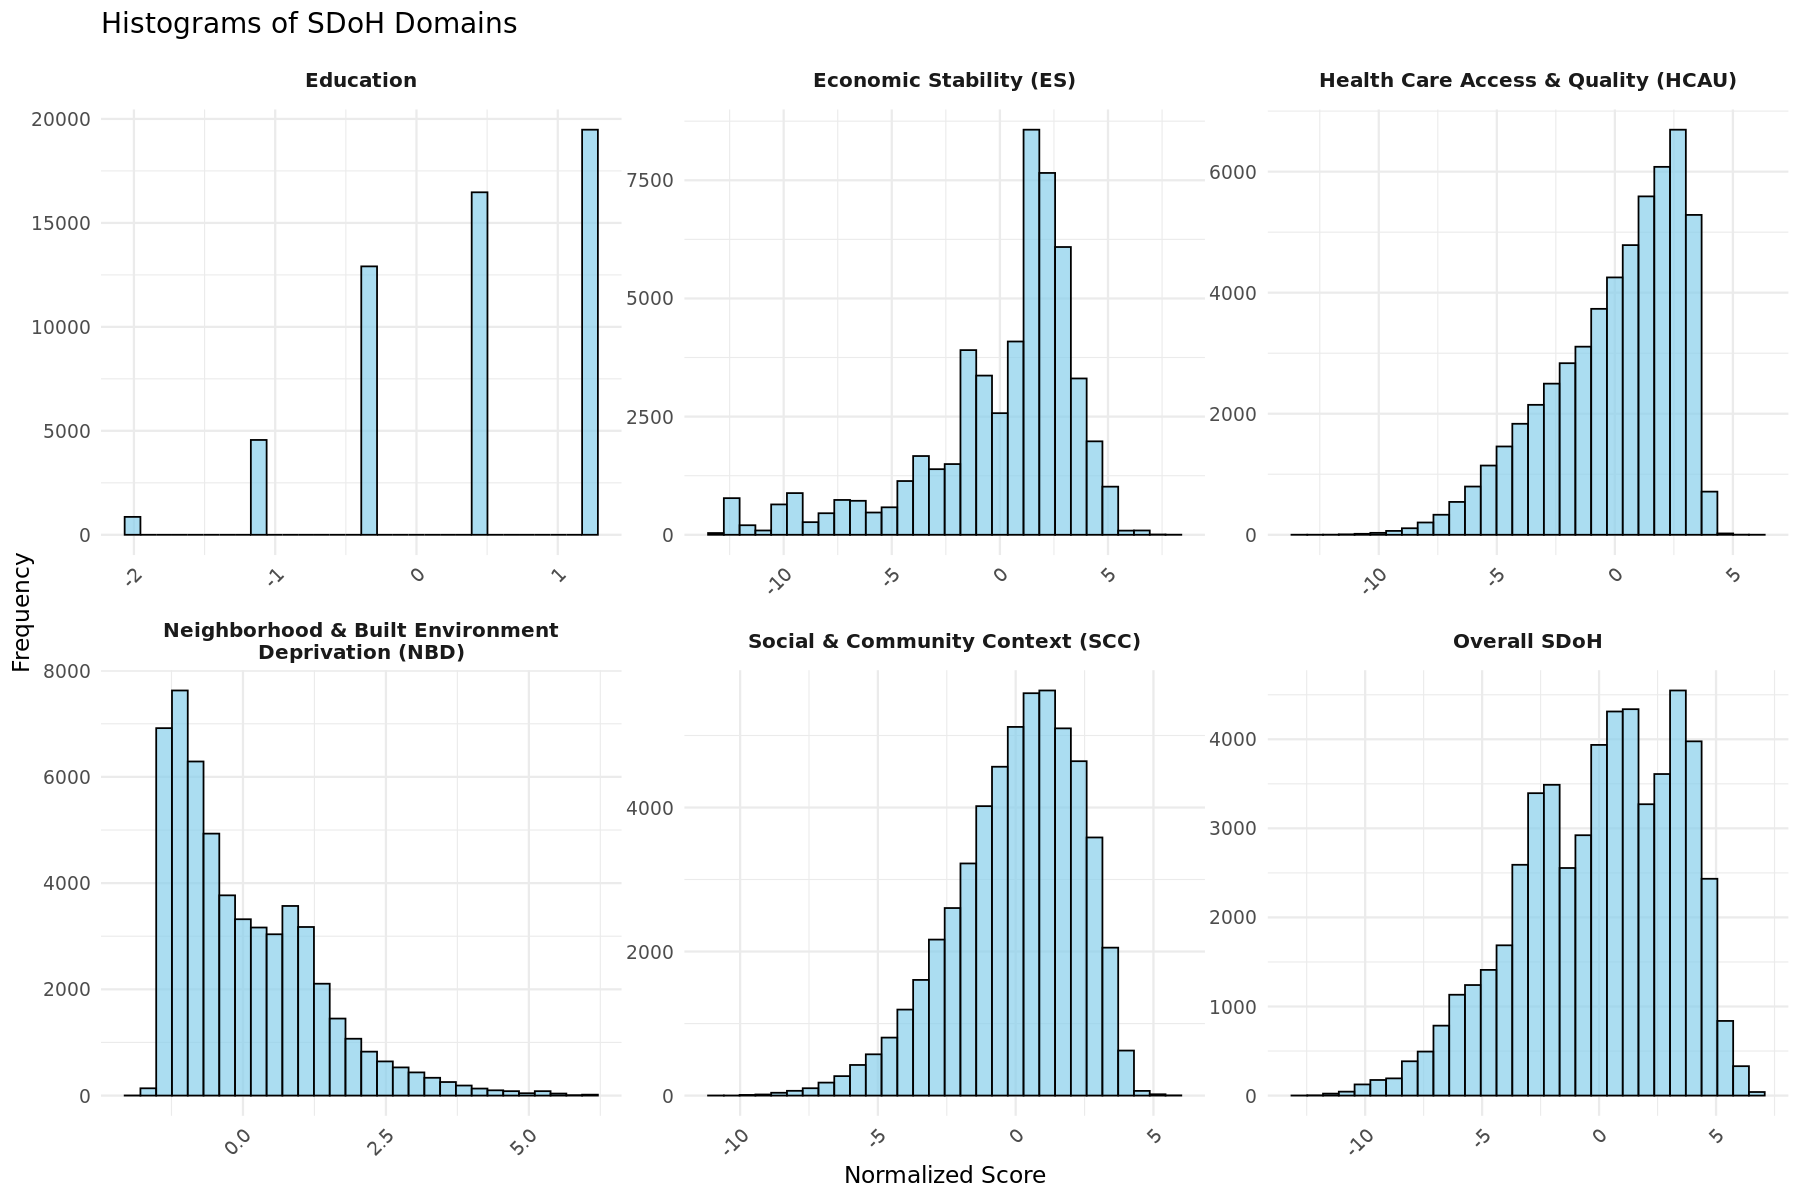

In [58]:
sdoh_labels <- c(
  SDOH = "Overall SDoH",
  SCC = "Social & Community Context (SCC)",
  NBE = "Neighborhood & Built Environment\nDeprivation (NBD)",
  ES = "Economic Stability (ES)",
  HCAU = "Health Care Access & Quality (HCAU)",
  Education = "Education"
)

sdoh_data_long <- sdoh_data %>%
  select(person_id, SDOH, SCC, NBE, ES, HCAU, Education) %>%  
  pivot_longer(
    cols = -person_id,  # All columns except person_id
    names_to = "Domain",
    values_to = "Score"
  ) 

#Step 2: Create facet-wrapped histograms
ggplot(sdoh_data_long, aes(x = Score)) +
  geom_histogram(bins = 30, fill = "skyblue", color = "black", alpha = 0.7, na.rm = TRUE) +
  facet_wrap(~ Domain, scales = "free", labeller = labeller(Domain = sdoh_labels)) +
  labs(
    title = "Histograms of SDoH Domains",
    x = "Normalized Score",
    y = "Frequency"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

# Step 3: Reshape back to wide format
sdoh_data_wide <- sdoh_data_long %>%
  pivot_wider(
    names_from = "Domain",
    values_from = "Score"
  )


In [59]:
# This snippet assumes that you run setup first

# This code saves your dataframe into a csv file in a "data" folder in Google Bucket

# Replace df with THE NAME OF YOUR DATAFRAME
my_dataframe <- sdoh_data_wide

# Replace 'test.csv' with THE NAME of the file you're going to store in the bucket (don't delete the quotation marks)
destination_filename <- 'CFA_domain_SDOH_scores'

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)

# Check if file is in the bucket
system(paste0("gsutil ls ", my_bucket, "/data/*.csv"), intern=T)


character(0)

[1] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/All_SDoH_data.csv"                                     
  [2] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/All_SDoH_data_domain_filtered_60.csv"                  
  [3] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/Area_level_disease_statistics.csv"                     
  [4] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/Case_Control_df.csv"                                   
  [5] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/Case_control_demographics_SDOH_cohort.csv"             
  [6] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/Case_control_demographics_SES_cohort.csv"              
  [7] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/Demographic_and_ancestry_covariates.csv"               
  [8] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_Afib.csv"                 
  [9] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_Asthma.csv"               
 [10] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_BreastC.csv"              
 [11] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_CHD.csv"                  
 [12] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_CKD.csv"                  
 [13] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_HyperC.csv"               
 [14] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_ProstateC.csv"            
 [15] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_t1d.csv"                  
 [16] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_HS_predictions_t2d.csv"                  
 [17] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_Afib.csv"                
 [18] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_Asthma.csv"              
 [19] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_BreastC.csv"             
 [20] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_CHD.csv"                 
 [21] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_CKD.csv"                 
 [22] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_HyperC.csv"              
 [23] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_ProstateC.csv"           
 [24] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_t1d.csv"                 
 [25] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHB_predictions_t2d.csv"                 
 [26] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_Afib.csv"                
 [27] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_Asthma.csv"              
 [28] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_BreastC.csv"             
 [29] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_CHD.csv"                 
 [30] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_CKD.csv"                 
 [31] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_HyperC.csv"              
 [32] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_ProstateC.csv"           
 [33] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/EN_stratified_NHW_predictions_t1d.csv"                 
 [34] "gs://fc-secure-672eeb92-4859-4ed9-9

# Area-level Data

In [60]:
# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'SES_cohort.csv'

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)


domains<-c('no_high_school_education', 'lower_median_income', 
           'no_health_insurance', 'vacant_housing', 'deprivation_index')

# Load the file into a dataframe
SES_cohort  <- read_csv(name_of_file_in_bucket) %>% select(all_of(c("person_id", domains)))

merged_data<-merge(sdoh_data, SES_cohort, on="person_id", how="left")

character(0)

Rows: 125295 Columns: 63
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (6): SexGender, where_born, military, healthcare, disabled, sexual_ori...
dbl  (46): person_id, race_unknown, age_today, LGBTQIA, ehr_length, relative...
lgl   (8): AIAN, Asian, Black, Mid, Multiple, PI, White, His
date  (3): date_of_birth, min_date, max_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [61]:
merged_data <- merged_data %>%
  mutate(SexGender = as.factor(SexGender)) %>%
  mutate(dummy = 1) %>%
  pivot_wider(
    names_from = SexGender,
    values_from = dummy,
    values_fill = 0,
    names_prefix = ""
  )

                                    
            

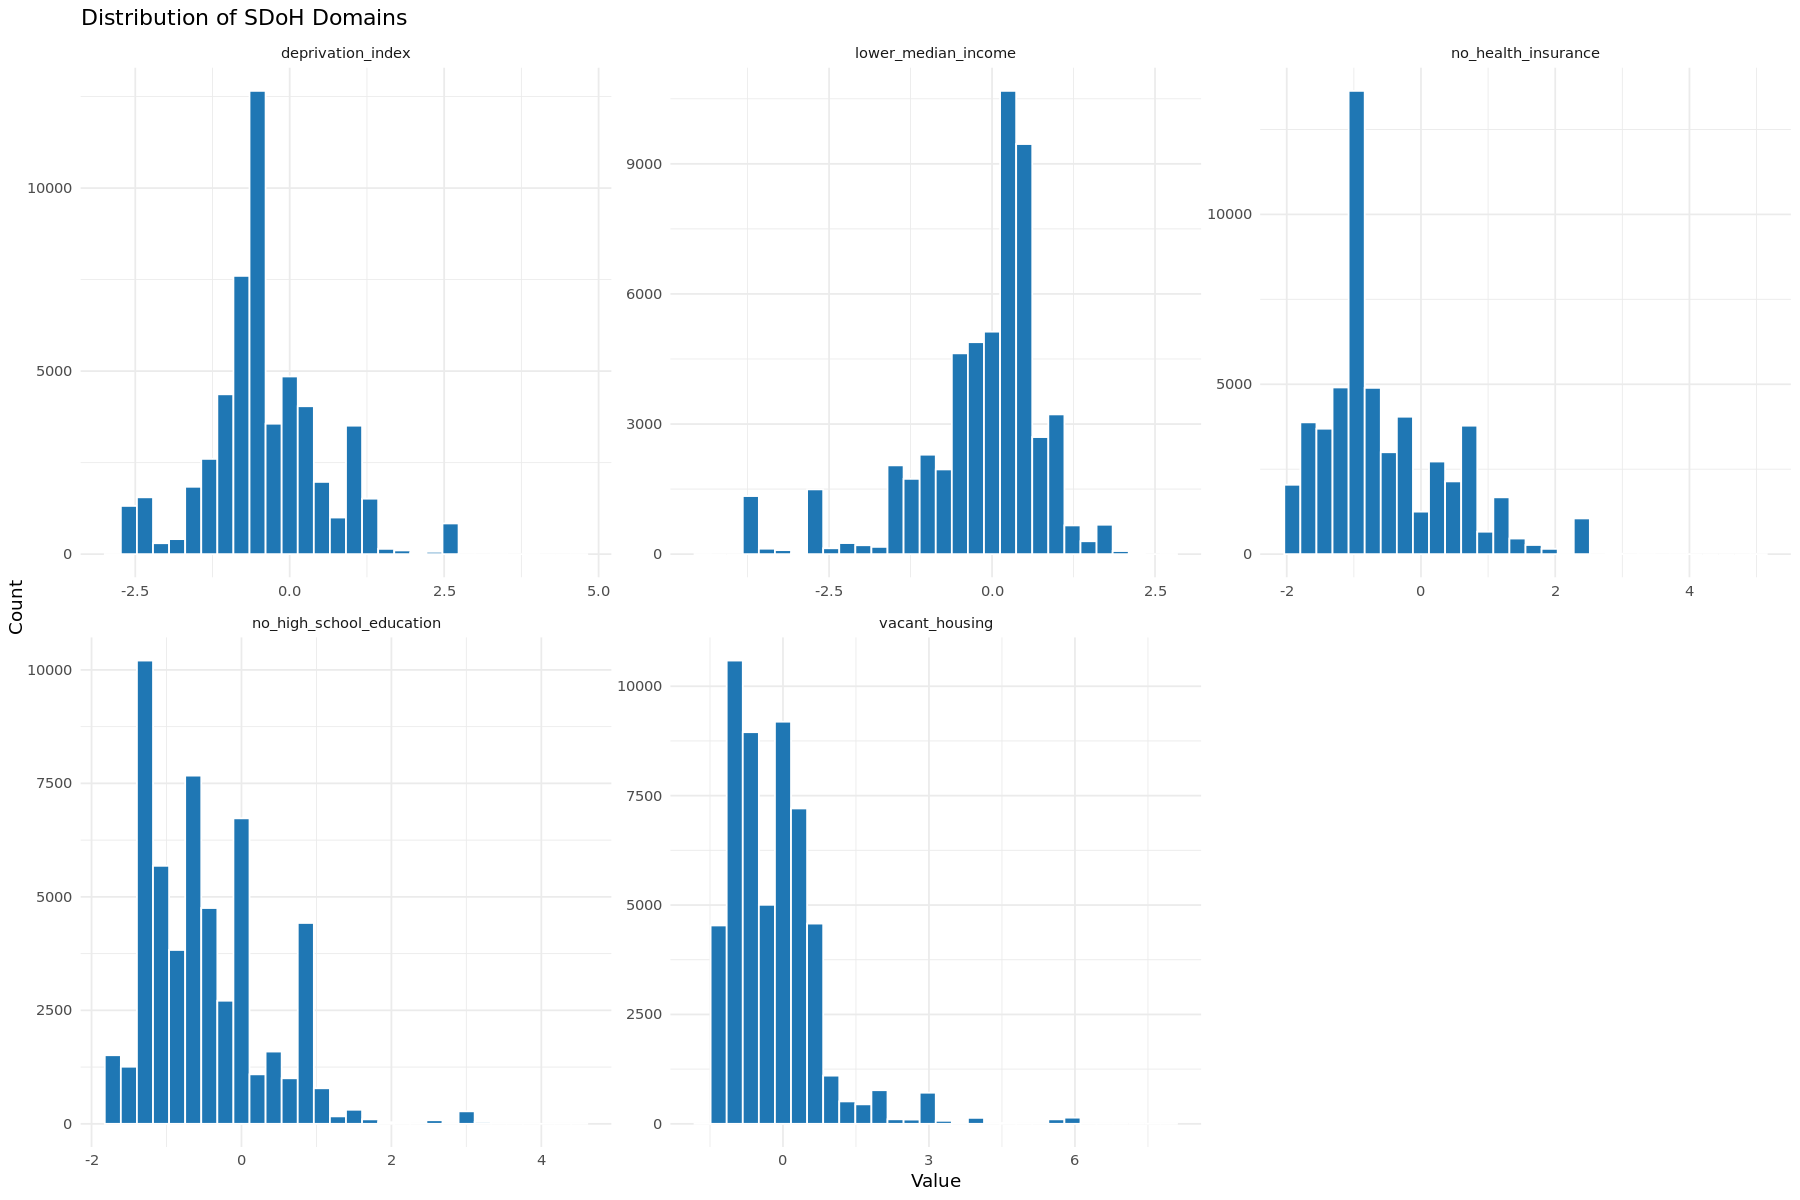

In [62]:

# Select only the domain columns plus person_id if needed
domain_df <- merged_data %>%
  select(all_of(domains))

# Pivot longer for facetting
domain_long <- domain_df %>%
  pivot_longer(
    cols = everything(),
    names_to = "domain",
    values_to = "value"
  )

# Plot facet-wrapped histograms
ggplot(domain_long, aes(x = value)) +
  geom_histogram(bins = 30, fill = "#1f77b4", color = "white") +
  facet_wrap(~domain, scales = "free") +
  theme_minimal() +
  labs(
    x = "Value",
    y = "Count",
    title = "Distribution of SDoH Domains"
  )


In [63]:
generate_sem_model <- function(disease, domain) {
  # Start with core predictors
  predictors <- c("age", "age2", "record_depth", "visit_frequency")
  
  # Conditional predictors based on disease
  if (disease %in% c("BreastC", "ProstateC")) {
    predictors <- c(predictors, "SGM")  # Include Cis_female and SGM for Breast Cancer
  } else if (disease %in% c("t1d", "CKD")) {
    predictors <- c(predictors, "Cis_male")  
  } else {
    predictors <- c(predictors, "Cis_male", "SGM")  # Include Cis_male and Cis_female for other diseases
  }

  # Add the domain
  predictors <- c(predictors, domain)
  
  # Generate the SEM syntax
  paste0(disease, " ~ ", paste(predictors, collapse = " + "))
}




In [64]:
# Function to fit SEM model and extract summary
fit_sem_model <- function(sem_model, data, disease, domain) {
    
  message("Fitting model for: ", disease)
    
  if (disease %in% c("t1d", "CKD")) {
    data <- filter(data, SGM == 0)
  }
    
 # Subset to non-missing outcome
  data_subset <- dplyr::filter(
    data,
    !is.na(.data[[disease]])
  )
    
  fit <- sem(sem_model, data = data_subset, estimator = "MLR")
    
    
  # ---- Coefficients (structural paths only) ----
  coef_df <- lavaan::parameterEstimates(
    fit,
    standardized = TRUE
  ) %>%
    dplyr::filter(
      op == "~",
      lhs == disease,
      !is.na(se)   # drop fixed / non-estimated paths
    ) %>%
    dplyr::select(
      Disease = lhs,
      term = rhs,
      estimate = est,
      std.error = se,
      z.value = z,
      p.value = pvalue,
      std_estimate = std.all
    )

  return(coef_df)
}

# Create combinations of diseases and domains
combinations <- expand_grid(disease = diseases, domain = domains)

# Fit SEM models
results <- combinations %>%
  mutate(
    sem_syntax = map2(disease, domain, generate_sem_model),
    model_results = pmap(list(sem_syntax, list(merged_data), disease, domain), fit_sem_model)
  ) %>%
  select(model_results) %>%
  unnest(model_results)


########Save Data############
my_dataframe <- results
destination_filename <- 'Area_level_disease_statistics.csv'
# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)
# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)


Fitting model for: Asthma

Fitting model for: Asthma

Fitting model for: Asthma

Fitting model for: Asthma

Fitting model for: Asthma

Fitting model for: Afib

Fitting model for: Afib

Fitting model for: Afib

Fitting model for: Afib

Fitting model for: Afib

Fitting model for: BreastC

Fitting model for: BreastC

Fitting model for: BreastC

Fitting model for: BreastC

Fitting model for: BreastC

Fitting model for: CKD

Fitting model for: CKD

Fitting model for: CKD

Fitting model for: CKD

Fitting model for: CKD

Fitting model for: CHD

Fitting model for: CHD

Fitting model for: CHD

Fitting model for: CHD

Fitting model for: CHD

Fitting model for: HyperC

Fitting model for: HyperC

Fitting model for: HyperC

Fitting model for: HyperC

Fitting model for: HyperC

Fitting model for: ProstateC

Fitting model for: ProstateC

Fitting model for: ProstateC

Fitting model for: ProstateC

Fitting model for: ProstateC

Fitting model for: t2d

Fitting model for: t2d

Fitting model for: t2d

Fit

character(0)